# K-Means clustering

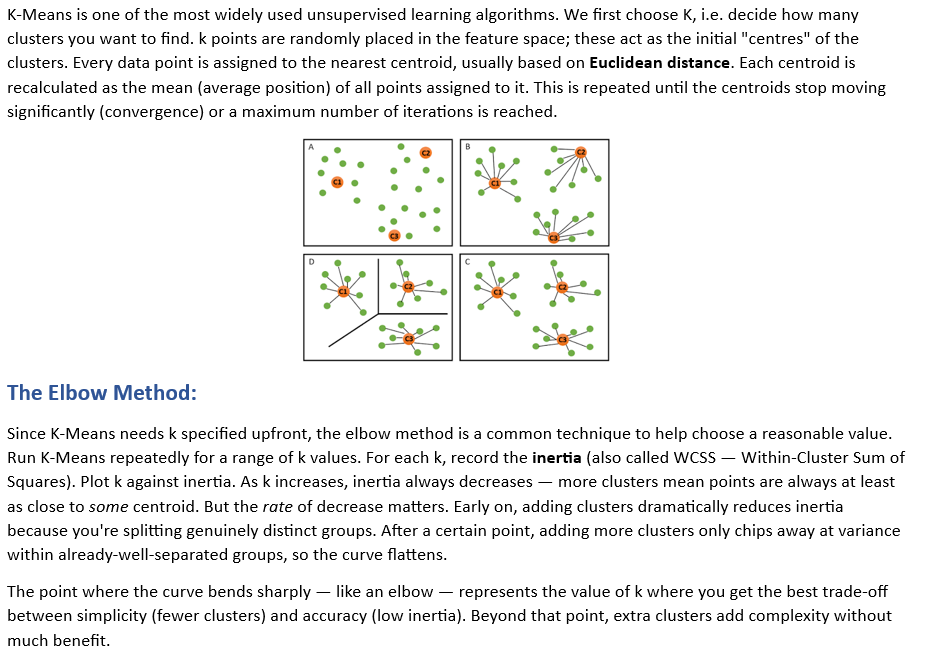
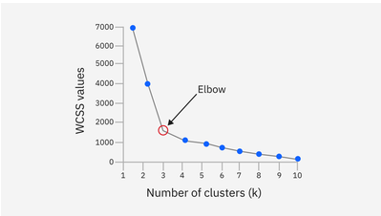

Original Data
      Name  Age  Income($)
0      Rob   27      70000
1  Michael   29      90000
2    Mohan   29      61000
3   Ismail   28      60000
4     Kory   42     150000
Dtata Scaled with Standard_Scaler
        Age  Income($)
0 -1.356055  -0.480684
1 -1.009157  -0.010159
2 -1.009157  -0.692421
3 -1.182606  -0.715947
4  1.245679   1.401417


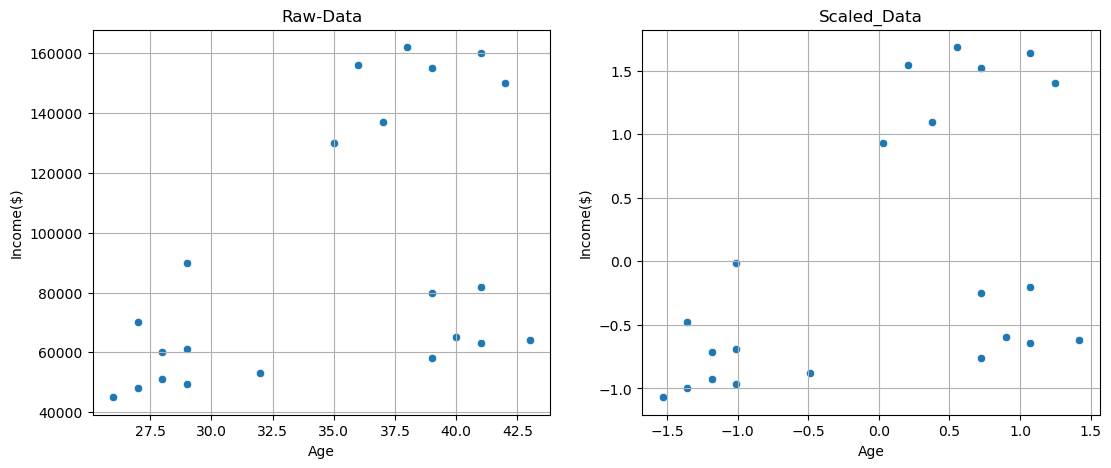

C:\ana\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ana\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ana\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ana\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can a

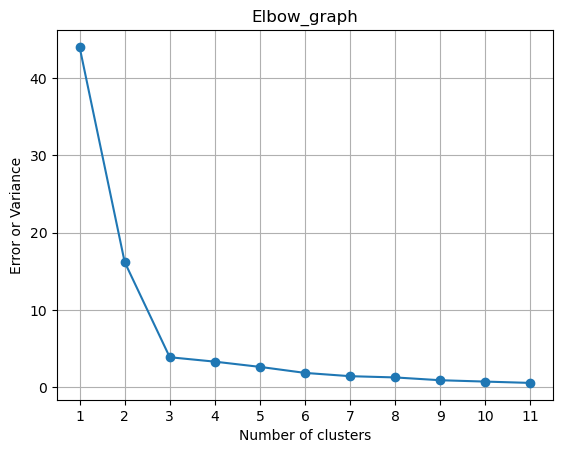

C:\ana\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


encoded clusters made by model
         Age  Income($)  Predictions
0  -1.356055  -0.480684            1
1  -1.009157  -0.010159            1
2  -1.009157  -0.692421            1
3  -1.182606  -0.715947            1
4   1.245679   1.401417            0
5   0.725332   1.519048            0
6   1.072230   1.636679            0
7   0.551883   1.683732            0
8   0.204985   1.542574            0
9   0.031536   0.930891            0
10  0.378434   1.095575            0
11 -1.529504  -1.068841            1
12 -1.356055  -0.998262            1
13 -1.182606  -0.927683            1
14 -1.009157  -0.962973            1
15 -0.488811  -0.880631            1
16  0.898781  -0.598316            2
17  1.072230  -0.645368            2
18  1.419128  -0.621842            2
19  0.725332  -0.245422            2
20  1.072230  -0.198369            2
21  0.725332  -0.762999            2


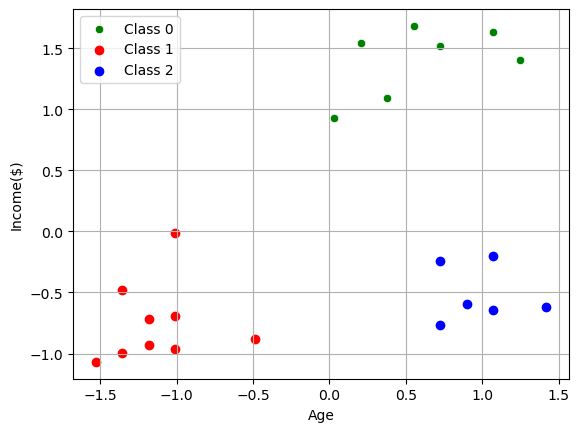

In [2]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:/Users/yashp/income.csv")
print('Original Data')
print(df.head(5))
df2 = df.drop(columns = 'Name')

scaler = StandardScaler()
df2[['Income($)', 'Age']] = scaler.fit_transform(df2[['Income($)', 'Age']])
print('Dtata Scaled with Standard_Scaler')
print(df2.head(5))

plt.figure(figsize = (13,5))
plt.subplot(1,2,1)
sns.scatterplot(x=df['Age'],y=df['Income($)'])
plt.grid()
plt.title('Raw-Data')
plt.subplot(1,2,2)
sns.scatterplot(x=df2['Age'],y=df2['Income($)'])
plt.grid()
plt.title('Scaled_Data')
plt.show()

error = []
for i in range(1,12):
    KM = KMeans(n_clusters=i)
    KM.fit(df2)
    error.append(KM.inertia_)

plt.plot(range(1,12),error,marker='o')
plt.xticks(range(1,12))
plt.grid()
plt.title('Elbow_graph')
plt.xlabel('Number of clusters')
plt.ylabel('Error or Variance')
plt.show()

Km = KMeans(n_clusters=3)
Km.fit(df2)
y_predict = Km.predict(df2[['Age','Income($)']])
df2['Predictions'] = y_predict
print('encoded clusters made by model')
print(df2)

df3 = df2[df2.Predictions == 0]
df4 = df2[df2.Predictions == 1]
df5 = df2[df2.Predictions == 2]

plt.grid()
sns.scatterplot(x=df3['Age'],y=df3['Income($)'],color='green',label='Class 0')
plt.scatter(df4['Age'],df4['Income($)'],color='red',label='Class 1')
plt.scatter(df5['Age'],df5['Income($)'],color='blue',label='Class 2')
plt.legend()
plt.show()